# Recolección y organización de datos TIBAITATA

## Datos de estaciones hidrometeorológicas de IDEAM

### Importar datos directamente de la API de datos abiertos colombia

In [4]:
# -*- coding: utf-8 -*-

import os
import pandas as pd
from pathlib import Path
from sodapy import Socrata
import matplotlib.pyplot as plt



# Crear carpeta para guardar datasets si no existe
os.makedirs("./Datasets", exist_ok=True)

client = Socrata("www.datos.gov.co", None)

results = client.get("hp9r-jxuu", limit=5000)

catalogoEstaciones = pd.DataFrame.from_records(results)

# Normalizar nombres de columnas para evitar problemas con caracteres especiales
catalogoEstaciones.columns = [str(col).strip() for col in catalogoEstaciones.columns]

catalogoEstaciones.head()


,codigo,nombre,categoria,tecnologia,estado,departamento,municipio,ubicaci_n,altitud,longitud,latitud,fecha_instalacion,area_operativa,area_hidrografica,zona_hidrografica,subzona_hidrografica,entidad,corriente,fecha_suspension
0,0024030700,COVARACHIA [24030700],Pluviométrica,Convencional,Activa,Boyacá,Covarachía,"{'latitude': '-72.739228889', 'longitude': '6....",2244,-72.739228889,6.500608056,15/06/1974,Area Operativa 06 - Boyacá-Casanare-Vichada,Magdalena Cauca,Sogamoso,Río Chicamocha,INSTITUTO DE HIDROLOGÍA METEOROLOGÍA Y ESTUDIO...,NaN,NaN
1,0035075040,INSTITUCION AGRICOLA MACANAL [35075040],Climatológica Principal,Convencional,Activa,Boyacá,Macanal,"{'latitude': '-73.316151944', 'longitude': '4....",1742,-73.316151944,4.974416111,15/07/1982,Area Operativa 06 - Boyacá-Casanare-Vichada,Orinoco,Meta,Río Garagoa,INSTITUTO DE HIDROLOGÍA METEOROLOGÍA Y ESTUDIO...,NaN,NaN
2,0035070170,NAZARETH [35070170],Pluviométrica,Convencional,Activa,Boyacá,Santa María,"{'latitude': '-73.219595', 'longitude': '4.735...",439,-73.219595,4.735228889,15/09/1972,Area Operativa 06 - Boyacá-Casanare-Vichada,Orinoco,Meta,Río Guavio,INSTITUTO DE HIDROLOGÍA METEOROLOGÍA Y ESTUDIO...,NaN,NaN
3,0035190030,CHAMEZA [35190030],Pluviográfica,Convencional,Activa,Casanare,Chámeza,"{'latitude': '-72.871813889', 'longitude': '5....",1129,-72.871813889,5.215341944,15/11/1974,Area Operativa 06 - Boyacá-Casanare-Vichada,Orinoco,Meta,Río Cusiana,INSTITUTO DE HIDROLOGÍA METEOROLOGÍA Y ESTUDIO...,NaN,NaN
4,0035060220,LA GLORIA [35060220],Pluviométrica,Convencional,Activa,Cundinamarca,Ubalá,"{'latitude': '-73.41977778', 'longitude': '4.8...",1845,-73.41977778,4.815694444,15/09/1964,Area Operativa 11 - Cundinamarca-Amazonas,Orinoco,Meta,Río Guavio,INSTITUTO DE HIDROLOGÍA METEOROLOGÍA Y ESTUDIO...,NaN,NaN


In [5]:
# Buscar la estación TIBAITATA [21205420]
# Se usa UTF-8 al guardar el CSV para que aparezcan bien los acentos

print(catalogoEstaciones.columns.tolist())

# Asegurar que la columna 'nombre' exista
if "nombre" not in catalogoEstaciones.columns:
    raise ValueError("No existe la columna 'nombre' en el DataFrame.")

# Filtro por nombre
# Este filtro se hace sobre texto normalizado en minúsculas para evitar errores con mayúsculas/acentos
catalogoEstaciones["nombre_norm"] = catalogoEstaciones["nombre"].astype(str).str.lower()

tibaitata_df = catalogoEstaciones[
    catalogoEstaciones["nombre_norm"].str.contains("tibaitata|tibaitatá", case=False, na=False, regex=True)
].copy()

# Filtro más preciso por código si existe
if "codigo" in catalogoEstaciones.columns:
    tibaitata_df = catalogoEstaciones[
        catalogoEstaciones["codigo"].astype(str)
        .str.contains("21205420", case=False, na=False, regex=False)
    ].copy()

# Mantener solo la fila final
if not tibaitata_df.empty:
    tibaitata_df = tibaitata_df.head(1).copy()

# Ver la fila final
display(tibaitata_df)

# Guardar con UTF-8 para conservar acentos y caracteres especiales
# La opción utf-8-sig ayuda también a Excel en Windows
if not tibaitata_df.empty:
    tibaitata_df.to_csv("./Datasets/tibaitata.csv", index=False, encoding="utf-8-sig")
else:
    print("No se encontró la estación TIBAITATA [21205420].")


['codigo', 'nombre', 'categoria', 'tecnologia', 'estado', 'departamento', 'municipio', 'ubicaci_n', 'altitud', 'longitud', 'latitud', 'fecha_instalacion', 'area_operativa', 'area_hidrografica', 'zona_hidrografica', 'subzona_hidrografica', 'entidad', 'corriente', 'fecha_suspension']


,codigo,nombre,categoria,tecnologia,estado,departamento,municipio,ubicaci_n,altitud,longitud,latitud,fecha_instalacion,area_operativa,area_hidrografica,zona_hidrografica,subzona_hidrografica,entidad,corriente,fecha_suspension,nombre_norm
3208,0021205420,TIBAITATA [21205420],Agrometeorológica,"Automática con Telemetría, Convencional",Activa,Cundinamarca,Mosquera,"{'latitude': '-74.205626', 'longitude': '4.688...",2543,-74.205626,4.688662,15/03/1954,Area Operativa 11 - Cundinamarca-Amazonas,Magdalena Cauca,Alto Magdalena,Río Bogotá,INSTITUTO DE HIDROLOGÍA METEOROLOGÍA Y ESTUDIO...,NaN,NaN,tibaitata [21205420]


### Radiación solar horaria: pasar a serie diaria

In [6]:

# Agrupar radiación solar horaria a diaria
actual_solar_files = [
    Path("./Datasets/Datos Tibaitata/Radiacion solar horaria/RadSolarHorarioTibaitata2005-2012.csv"),
    Path("./Datasets/Datos Tibaitata/Radiacion solar horaria/RadSolarHorariaTibaitata2012-2018.csv"),
    Path("./Datasets/Datos Tibaitata/Radiacion solar horaria/RadSolarHorarioTibaitata2018-2026.csv"),
]

frames_rad = []
for file in actual_solar_files:
    df = pd.read_csv(file)
    df.columns = [str(col).strip() for col in df.columns]
    df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")
    df["Valor"] = pd.to_numeric(df["Valor"], errors="coerce")
    df = df.dropna(subset=["Fecha", "Valor"]).copy()
    df["Fecha"] = df["Fecha"].dt.normalize()
    df["NivelAprobacion"] = "Calculado"
    df["CodigoEstacion"] = df["CodigoEstacion"].astype(int)
    df["NombreEstacion"] = df["NombreEstacion"].astype(str).str.strip()
    df["Variable"] = df["Variable"].astype(str).str.strip()
    df["Parametro"] = df["Parametro"].astype(str).str.strip()
    df["Unidad"] = df["Unidad"].astype(str).str.strip()

    df_diario = (
        df.groupby(
            ["CodigoEstacion", "NombreEstacion", "Variable", "Parametro", "Unidad", "Fecha"],
            as_index=False,
        )
        .agg(Valor=("Valor", "sum"))
    )
    df_diario["NivelAprobacion"] = "Calculado"
    frames_rad.append(df_diario)

# Unificar en una sola serie diaria de radiación
df_rad_diaria = pd.concat(frames_rad, ignore_index=True).sort_values("Fecha").reset_index(drop=True)

print("Radiación solar diaria consolidada:")
print(df_rad_diaria.head(10).to_string(index=False))
print(f"\nNúmero de filas: {len(df_rad_diaria)}")
print(f"Rango de fechas: {df_rad_diaria['Fecha'].min()} a {df_rad_diaria['Fecha'].max()}")

# Guardar la serie diaria generada para usarla luego en la base consolidada
output_path = Path("./Datasets/Datos Tibaitata/RadSolarDiariaTibaitata.csv")
df_rad_diaria.to_csv(output_path, index=False, encoding="utf-8-sig")
print(f"\nArchivo guardado: {output_path}")


Radiación solar diaria consolidada:
 CodigoEstacion             NombreEstacion  Variable                               Parametro Unidad      Fecha  Valor NivelAprobacion
       21206990 TIBAITATA - AUT [21206990] RAD SOLAR Radiación solar global horaria VALIDADA Wh/m^2 2005-02-02 1696.5       Calculado
       21206990 TIBAITATA - AUT [21206990] RAD SOLAR Radiación solar global horaria VALIDADA Wh/m^2 2005-02-03 4480.5       Calculado
       21206990 TIBAITATA - AUT [21206990] RAD SOLAR Radiación solar global horaria VALIDADA Wh/m^2 2005-02-04 2363.3       Calculado
       21206990 TIBAITATA - AUT [21206990] RAD SOLAR Radiación solar global horaria VALIDADA Wh/m^2 2005-02-05 3137.0       Calculado
       21206990 TIBAITATA - AUT [21206990] RAD SOLAR Radiación solar global horaria VALIDADA Wh/m^2 2005-02-06 1992.7       Calculado
       21206990 TIBAITATA - AUT [21206990] RAD SOLAR Radiación solar global horaria VALIDADA Wh/m^2 2005-02-07 3453.2       Calculado
       21206990 TIBAITATA 

## Datos para evapotranspiracion

### Inspección inicial de cada CSV



In [7]:
base_path = Path("./Datasets/Datos Tibaitata")
csv_files = sorted(base_path.glob("*.csv"))

print(f"Se encontraron {len(csv_files)} archivos CSV")
for file in csv_files:
    df = pd.read_csv(file)
    print(f"\n=== {file.name} ===")
    print(f"shape: {df.shape}")
    print(df.info())
    print(df.head(2).to_string(index=False))


Se encontraron 5 archivos CSV

=== HumedadRelativaTibaitata .csv ===
shape: (5531, 8)
<class 'pandas.DataFrame'>
RangeIndex: 5531 entries, 0 to 5530
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CodigoEstacion   5531 non-null   int64  
 1   NombreEstacion   5531 non-null   str    
 2   Variable         5531 non-null   str    
 3   Parametro        5531 non-null   str    
 4   Fecha            5531 non-null   str    
 5   Unidad           5531 non-null   str    
 6   Valor            5531 non-null   float64
 7   NivelAprobacion  5531 non-null   str    
dtypes: float64(1), int64(1), str(6)
memory usage: 345.8 KB
None
 CodigoEstacion             NombreEstacion     Variable                                         Parametro            Fecha Unidad     Valor NivelAprobacion
       21206990 TIBAITATA - AUT [21206990] HUM RELATIVA Humedad relativa del aire a 2 metros media diaria 2005-02-02 00:00      % 89.53125

### Normalización y consolidación

In [8]:
base_path = Path("./Datasets/Datos Tibaitata")

def normalizar_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [str(col).strip() for col in df.columns]
    df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")
    df["Valor"] = pd.to_numeric(df["Valor"], errors="coerce")
    df["Unidad"] = df["Unidad"].astype(str).str.strip()
    df["NombreEstacion"] = df["NombreEstacion"].astype(str).str.strip()
    df["Variable"] = df["Variable"].astype(str).str.strip()
    df["Parametro"] = df["Parametro"].astype(str).str.strip()
    return df.dropna(subset=["Fecha", "Valor"]).sort_values("Fecha").reset_index(drop=True)

# Cargar todos los CSV y normalizarlos
frames = {}
for csv_path in sorted(base_path.glob("*.csv")):
    df = pd.read_csv(csv_path)
    frames[csv_path.name] = normalizar_df(df)
    print(f"{csv_path.name}: {frames[csv_path.name].shape[0]} filas, fechas desde {frames[csv_path.name]['Fecha'].min()} hasta {frames[csv_path.name]['Fecha'].max()}")

# Concatenar en un solo DataFrame para análisis integrado
df_tibaitata = pd.concat(frames.values(), ignore_index=True)
df_tibaitata = df_tibaitata.sort_values(["Fecha", "Variable"]).reset_index(drop=True)

print("\nDataFrame consolidado:")
print(df_tibaitata.info())
print(df_tibaitata.head(3).to_string(index=False))

# Unidades estandarizadas (solo para visualización y no para perder la original)
unit_map = {
    "degC": "°C",
    "Wh/m^2": "Wh/m²",
    "m/s": "m/s",
    "%": "%",
}
df_tibaitata["Unidad_esta"] = df_tibaitata["Unidad"].map(unit_map).fillna(df_tibaitata["Unidad"])

print("\nUnidades presentes:")
print(df_tibaitata["Unidad_esta"].value_counts())

# Al final, este DataFrame queda listo para pivotar por fecha y preparar la variable objetivo de evapotranspiración.


HumedadRelativaTibaitata .csv: 5531 filas, fechas desde 2005-02-02 00:00:00 hasta 2023-03-16 00:00:00
RadSolarDiariaTibaitata.csv: 6029 filas, fechas desde 2005-02-02 00:00:00 hasta 2022-10-31 00:00:00
TemperaturaMaximaTibaitata.csv: 7027 filas, fechas desde 2005-01-03 00:00:00 hasta 2026-01-01 00:00:00
TemperaturaMinimaTibaitata.csv: 14307 filas, fechas desde 2005-01-01 00:00:00 hasta 2026-01-01 00:00:00
VelViento10MinDiariaTibaitata.csv: 3497 filas, fechas desde 2005-02-02 00:00:00 hasta 2023-03-16 00:00:00

DataFrame consolidado:
<class 'pandas.DataFrame'>
RangeIndex: 36391 entries, 0 to 36390
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   CodigoEstacion   36391 non-null  int64         
 1   NombreEstacion   36391 non-null  str           
 2   Variable         36391 non-null  str           
 3   Parametro        36391 non-null  str           
 4   Fecha            36391 non-null  datetime

### Análisis temporal de disponibilidad

Disponibilidad diaria por parámetro y por año (%)
      Humedad relativa del aire a 2 metros media diaria  \
anio                                                      
2005                                               86.6   
2006                                               82.5   
2007                                               91.8   
2008                                               94.5   
2009                                               77.8   
2010                                               89.0   
2011                                               87.4   
2012                                               59.0   
2013                                               70.1   
2014                                               92.6   
2015                                               94.0   
2016                                               97.5   
2017                                               93.7   
2018                                               95.1   
2019  

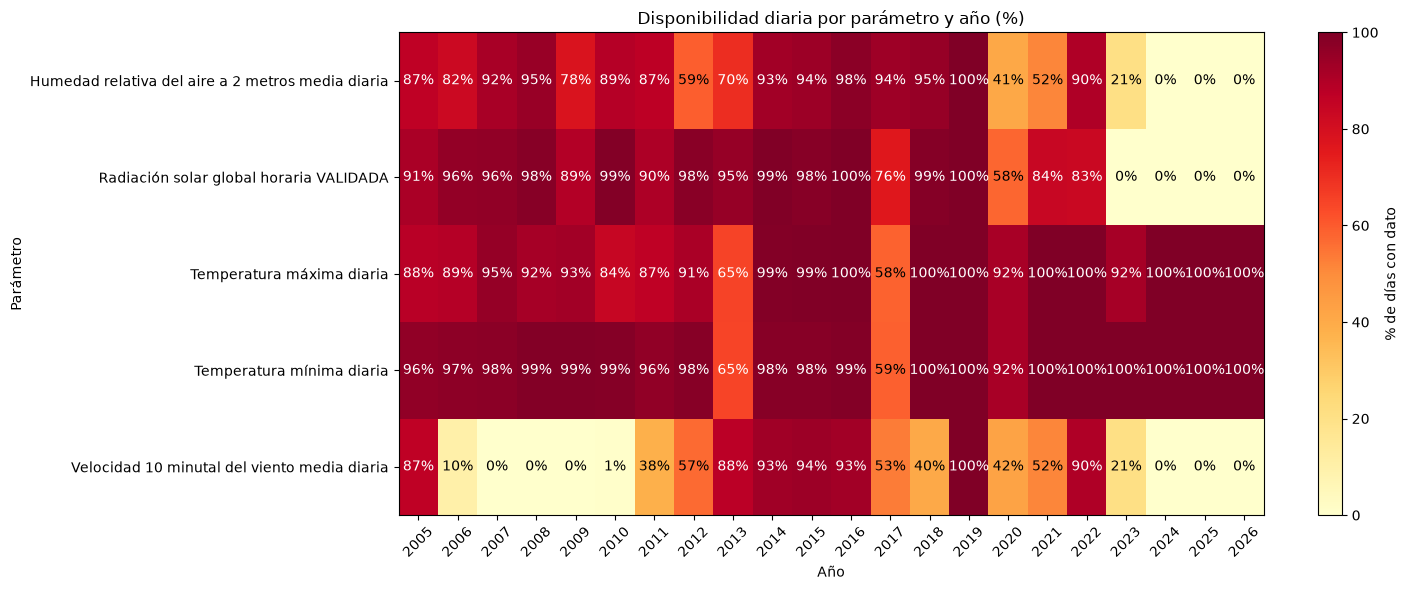

In [9]:
# Medición de disponibilidad diaria por parámetro y por año
# La unidad de análisis sigue siendo el día, pero ahora la agregación se hace por parámetro más específico.
df_disponibilidad = df_tibaitata.copy()
df_disponibilidad['anio'] = df_disponibilidad['Fecha'].dt.year
df_disponibilidad['parametro_limpio'] = df_disponibilidad['Parametro'].fillna(df_disponibilidad['Variable']).astype(str).str.strip()

# Mantener una sola observación por parámetro y por día
dias_con_dato = (
    df_disponibilidad.groupby(['parametro_limpio', 'Fecha'])['Valor'].count().reset_index()
)
dias_con_dato = dias_con_dato.rename(columns={'Valor': 'n_registros'})

# Calendario completo para comparar cada año
fecha_min = df_disponibilidad['Fecha'].min()
fecha_max = df_disponibilidad['Fecha'].max()
calendario = pd.DataFrame({'Fecha': pd.date_range(fecha_min, fecha_max, freq='D')})
calendario['anio'] = calendario['Fecha'].dt.year

param_year = []
for parametro in sorted(df_disponibilidad['parametro_limpio'].dropna().unique()):
    param_dias = dias_con_dato[dias_con_dato['parametro_limpio'] == parametro][['Fecha']].copy()
    param_dias['anio'] = param_dias['Fecha'].dt.year
    dias_disponibles = param_dias.groupby('anio').size()
    dias_totales = calendario.groupby('anio').size()
    pct = (dias_disponibles / dias_totales * 100).fillna(0).rename(parametro)
    param_year.append(pct)

disponibilidad_anio = pd.concat(param_year, axis=1).fillna(0).sort_index()

print('Disponibilidad diaria por parámetro y por año (%)')
print(disponibilidad_anio.round(1))
print('Disponibilidad promedio por parámetro (%)')
print(disponibilidad_anio.mean().round(1).sort_values(ascending=False))

heatmap_df = disponibilidad_anio.copy().T

fig, ax = plt.subplots(figsize=(15, max(6, len(heatmap_df.index) * 0.6)))
im = ax.imshow(heatmap_df.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)


# Visualización resumida: heatmap de disponibilidad por año y parámetro

ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns, rotation=45)
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        value = heatmap_df.iloc[i, j]
        ax.text(j, i, f'{value:.0f}%', ha='center', va='center', color='black' if value < 60 else 'white')

ax.set_title('Disponibilidad diaria por parámetro y año (%)')
ax.set_xlabel('Año')
ax.set_ylabel('Parámetro')
fig.colorbar(im, ax=ax, label='% de días con dato')
plt.tight_layout()
plt.show()


### Segmentación por años con cobertura aceptable

Los años con menos del 60% de días con dato para la mayoría de los parámetros se excluyen del análisis principal para no introducir ruido. La lista que indicaste se puede separar en bloque principal y bloque secundario según su cobertura real.

Años principales (>=60% de cobertura todos los parámetros): [2005, 2013, 2014, 2015, 2016, 2019, 2022]
Años secundarios (entre 40% y 60%): [2012, 2017, 2018, 2020, 2021]
Años excluidos por baja cobertura: [2006, 2007, 2008, 2009, 2010, 2011, 2023, 2024, 2025, 2026]

Filas en análisis principal: 14249
Filas en análisis secundario: 8508
Filas en selección del usuario: 22757
Filas excluidas: 13634

Conteo de filas por año en la selección del usuario:
Fecha
2005    1960
2012    1810
2013    1633
2014    2124
2015    2129
2016    2158
2017    1454
2018    1949
2019    2190
2020    1520
2021    1775
2022    2055
Name: count, dtype: int64

Conteo por segmento en el DataFrame principal:
segmento
principal     14249
excluido      13634
secundario     8508
Name: count, dtype: int64


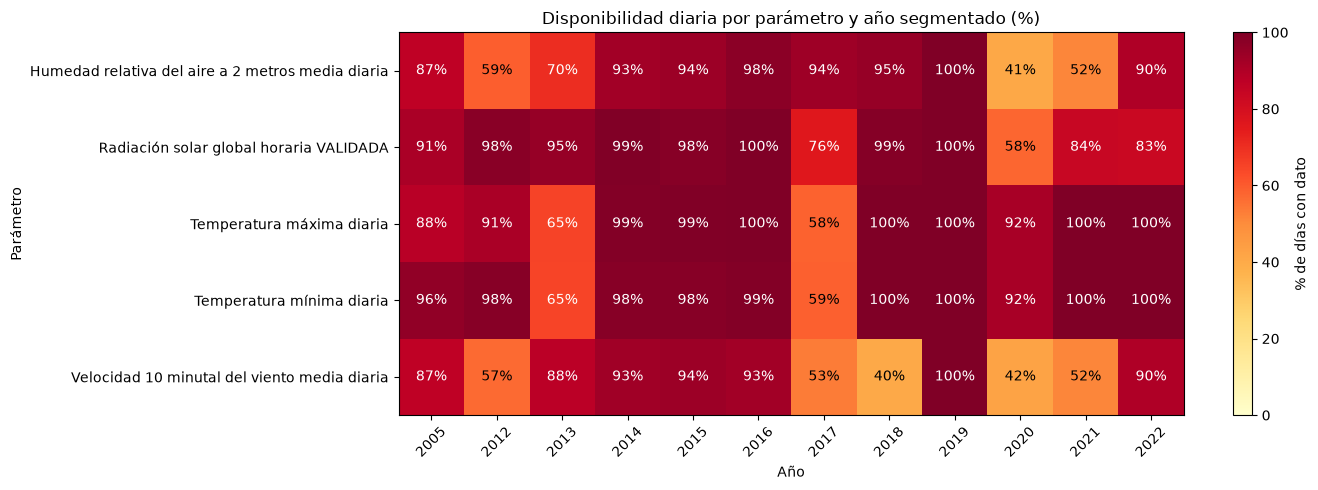

In [10]:

# Cálculo de disponibilidad por año (si por alguna razón no existe en el notebook)
if 'disponibilidad_anio' not in globals():
    df_segment = df_tibaitata.copy()
    df_segment['anio'] = df_segment['Fecha'].dt.year
    df_segment['parametro_limpio'] = df_segment['Parametro'].fillna(df_segment['Variable']).astype(str).str.strip()

    dias_con_dato = (
        df_segment.groupby(['parametro_limpio', 'Fecha'])['Valor'].count().reset_index().rename(columns={'Valor': 'n_registros'})
    )

    fecha_min = df_segment['Fecha'].min()
    fecha_max = df_segment['Fecha'].max()
    calendario = pd.DataFrame({'Fecha': pd.date_range(fecha_min, fecha_max, freq='D')})
    calendario['anio'] = calendario['Fecha'].dt.year

    param_year = []
    for parametro in sorted(df_segment['parametro_limpio'].dropna().unique()):
        param_dias = dias_con_dato[dias_con_dato['parametro_limpio'] == parametro][['Fecha']].copy()
        param_dias['anio'] = param_dias['Fecha'].dt.year
        dias_disponibles = param_dias.groupby('anio').size()
        dias_totales = calendario.groupby('anio').size()
        pct = (dias_disponibles / dias_totales * 100).fillna(0).rename(parametro)
        param_year.append(pct)

    disponibilidad_anio = pd.concat(param_year, axis=1).fillna(0).sort_index()

# Criterios de segmentación
threshold_principal = 60
threshold_secundario = 40
user_years = [2005, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]

principal_years = disponibilidad_anio[(disponibilidad_anio >= threshold_principal).all(axis=1)].index.tolist()
secondary_years = [
    year for year in user_years
    if year in disponibilidad_anio.index and year not in principal_years and (disponibilidad_anio.loc[year] >= threshold_secundario).all()
]
excluded_years = sorted(set(disponibilidad_anio.index) - set(user_years))

# DataFrames por segmento
principal_df = df_tibaitata[df_tibaitata['Fecha'].dt.year.isin(principal_years)].copy()
secondary_df = df_tibaitata[df_tibaitata['Fecha'].dt.year.isin(secondary_years)].copy()
selected_user_df = df_tibaitata[df_tibaitata['Fecha'].dt.year.isin(user_years)].copy()
excluded_df = df_tibaitata[df_tibaitata['Fecha'].dt.year.isin(excluded_years)].copy()

# Etiqueta por segmento para conservar la clasificación en el DataFrame principal
segment_map = {year: 'principal' for year in principal_years}
segment_map.update({year: 'secundario' for year in secondary_years})
segment_map.update({year: 'excluido' for year in disponibilidad_anio.index if year not in principal_years and year not in secondary_years})

df_tibaitata['segmento'] = df_tibaitata['Fecha'].dt.year.map(segment_map).fillna('excluido')

print(f"Años principales (>={threshold_principal}% de cobertura todos los parámetros): {principal_years}")
print(f"Años secundarios (entre {threshold_secundario}% y {threshold_principal}%): {secondary_years}")
print(f"Años excluidos por baja cobertura: {excluded_years}")
print(f"\nFilas en análisis principal: {len(principal_df)}")
print(f"Filas en análisis secundario: {len(secondary_df)}")
print(f"Filas en selección del usuario: {len(selected_user_df)}")
print(f"Filas excluidas: {len(excluded_df)}")
print("\nConteo de filas por año en la selección del usuario:")
print(selected_user_df['Fecha'].dt.year.value_counts().sort_index())
print("\nConteo por segmento en el DataFrame principal:")
print(df_tibaitata['segmento'].value_counts())

# Heatmap después de segmentar: mostrar solo años con uso viable
selected_years = sorted(set(principal_years) | set(secondary_years))
segment_heatmap = disponibilidad_anio.loc[selected_years].copy().T

fig, ax = plt.subplots(figsize=(14, max(5, len(segment_heatmap.index) * 0.7)))
im = ax.imshow(segment_heatmap.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)

ax.set_xticks(range(len(segment_heatmap.columns)))
ax.set_xticklabels(segment_heatmap.columns, rotation=45)
ax.set_yticks(range(len(segment_heatmap.index)))
ax.set_yticklabels(segment_heatmap.index)

for i in range(segment_heatmap.shape[0]):
    for j in range(segment_heatmap.shape[1]):
        value = segment_heatmap.iloc[i, j]
        ax.text(j, i, f'{value:.0f}%', ha='center', va='center', color='black' if value < 60 else 'white')

ax.set_title('Disponibilidad diaria por parámetro y año segmentado (%)')
ax.set_xlabel('Año')
ax.set_ylabel('Parámetro')
fig.colorbar(im, ax=ax, label='% de días con dato')
plt.tight_layout()
plt.show()


In [11]:

# -----------------------------------------------------------------------------
# Ventanas temporales con disponibilidad completa (100%)
# Una ventana solo es válida si todos los días dentro de ella tienen todos los
# parámetros disponibles. Si falta 1 parámetro en cualquiera de los días,
# esa ventana se descarta.
# -----------------------------------------------------------------------------

# Años elegibles para análisis temporal de ventanas
analysis_years = sorted(set(principal_years) | set(secondary_years))
analysis_df = df_tibaitata[df_tibaitata['Fecha'].dt.year.isin(analysis_years)].copy()

# Normalizar el nombre del parámetro para mantener consistencia
analysis_df['parametro_limpio'] = analysis_df['Parametro'].fillna(analysis_df['Variable']).astype(str).str.strip()

# Tabla diaria de disponibilidad por parámetro
parametros = sorted(analysis_df['parametro_limpio'].unique())
daily_summary = (
    analysis_df.groupby(['Fecha', 'parametro_limpio'])['Valor']
    .count()
    .reset_index(name='n_registros')
    .pivot_table(index='Fecha', columns='parametro_limpio', values='n_registros', aggfunc='sum')
    .fillna(0)
)

for param in parametros:
    if param not in daily_summary.columns:
        daily_summary[param] = 0

# Día completo = todos los parámetros presentes para ese día
# (cada columna debe tener valor > 0)
daily_summary['n_parametros_disponibles'] = (daily_summary[parametros] > 0).sum(axis=1)
daily_summary['n_parametros_totales'] = len(parametros)
daily_summary['dia_completo'] = daily_summary['n_parametros_disponibles'] == daily_summary['n_parametros_totales']
daily_summary = daily_summary.reset_index().rename(columns={'index': 'Fecha'})
daily_summary['Fecha'] = pd.to_datetime(daily_summary['Fecha'])
daily_summary['anio'] = daily_summary['Fecha'].dt.year

# Generar ventanas válidas para 7, 15 y 30 días
windows_by_size = {}
for window_size in [7, 15, 30]:
    ventana_records = []

    for year in analysis_years:
        year_df = daily_summary[daily_summary['anio'] == year].sort_values('Fecha').copy()
        year_calendar = pd.date_range(f'{year}-01-01', f'{year}-12-31', freq='D')

        completeness = pd.Series(False, index=year_calendar)
        result_map = pd.Series(year_df['dia_completo'].astype(bool).values, index=year_df['Fecha'])
        completeness.loc[result_map.index] = result_map.values

        for start in year_calendar[:-window_size + 1]:
            window_dates = pd.date_range(start=start, periods=window_size, freq='D')
            is_valid = completeness.loc[window_dates].all()
            if is_valid:
                ventana_records.append({
                    'anio': year,
                    'window_size': window_size,
                    'inicio': start,
                    'fin': start + pd.Timedelta(days=window_size - 1),
                    'dias_validos': window_size,
                    'requisito': '100% completitud diaria'
                })

    windows_by_size[window_size] = pd.DataFrame(ventana_records)
    print(f"\nVentanas válidas de {window_size} días: {len(windows_by_size[window_size])}")
    print(windows_by_size[window_size].head(10).to_string(index=False))

# DataFrames separados para cada tipo de ventana
ventana_7d = windows_by_size[7].copy()
ventana_15d = windows_by_size[15].copy()
ventana_30d = windows_by_size[30].copy()

print("\nResumen por tamaño de ventana:")
for window_size, df_window in windows_by_size.items():
    print(f"- {window_size} días: {len(df_window)} ventanas válidas")

# Tabla consolidada para exportación o análisis posterior
ventanas_validas = pd.concat(
    [
        df.assign(window_size=window_size)
        for window_size, df in windows_by_size.items()
    ],
    ignore_index=True
)

print("\nTabla consolidada de ventanas válidas:")
print(ventanas_validas.head(20).to_string(index=False))



Ventanas válidas de 7 días: 1945
 anio  window_size     inicio        fin  dias_validos               requisito
 2005            7 2005-02-02 2005-02-08             7 100% completitud diaria
 2005            7 2005-02-03 2005-02-09             7 100% completitud diaria
 2005            7 2005-02-04 2005-02-10             7 100% completitud diaria
 2005            7 2005-02-14 2005-02-20             7 100% completitud diaria
 2005            7 2005-02-15 2005-02-21             7 100% completitud diaria
 2005            7 2005-02-16 2005-02-22             7 100% completitud diaria
 2005            7 2005-02-17 2005-02-23             7 100% completitud diaria
 2005            7 2005-02-18 2005-02-24             7 100% completitud diaria
 2005            7 2005-02-19 2005-02-25             7 100% completitud diaria
 2005            7 2005-02-20 2005-02-26             7 100% completitud diaria

Ventanas válidas de 15 días: 1465
 anio  window_size     inicio        fin  dias_validos        

Duplicados exactos por fecha + parámetro + valor:
 CodigoEstacion       NombreEstacion    Variable                 Parametro      Fecha Unidad  Valor NivelAprobacion Unidad_esta  segmento          parametro_limpio
       21205420 TIBAITATA [21205420] TEMPERATURA Temperatura máxima diaria 2005-01-03   degC   19.2      Definitivo          °C principal Temperatura máxima diaria
       21205420 TIBAITATA [21205420] TEMPERATURA Temperatura máxima diaria 2005-01-03   degC   19.2      Definitivo          °C principal Temperatura máxima diaria
       21205420 TIBAITATA [21205420] TEMPERATURA Temperatura máxima diaria 2005-01-04   degC   20.8      Definitivo          °C principal Temperatura máxima diaria
       21205420 TIBAITATA [21205420] TEMPERATURA Temperatura máxima diaria 2005-01-04   degC   20.8      Definitivo          °C principal Temperatura máxima diaria
       21205420 TIBAITATA [21205420] TEMPERATURA Temperatura máxima diaria 2005-01-05   degC   21.0      Definitivo          °C pr

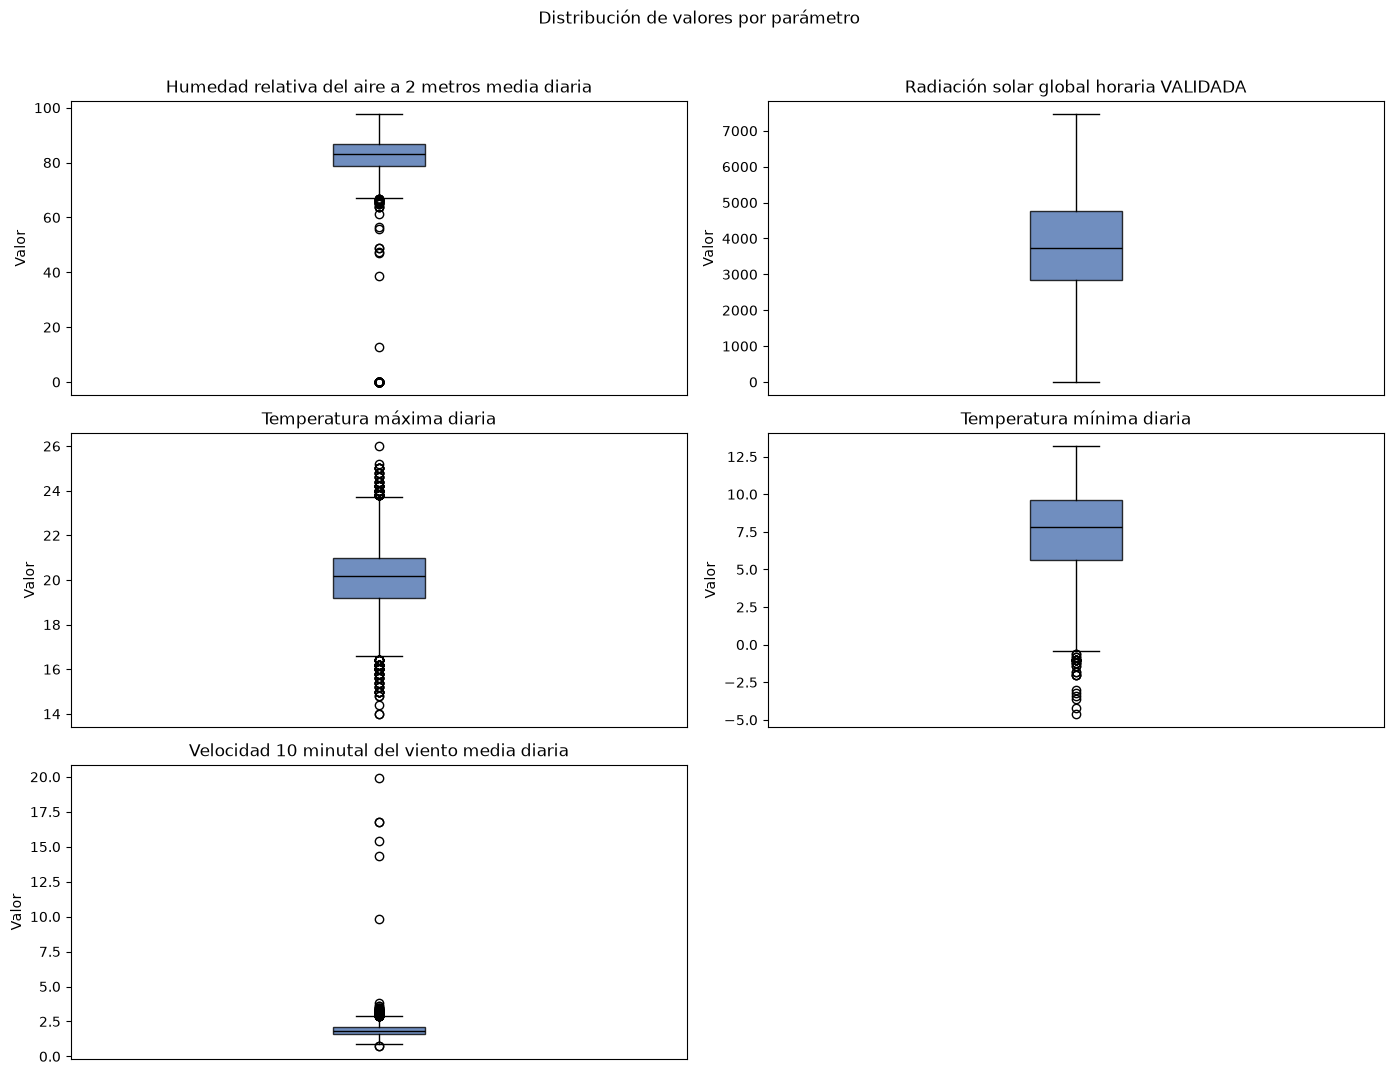


Resumen general de posibles valores anómalos por parámetro:
- Humedad relativa del aire a 2 metros media diaria: 104 valores atípicos según IQR
- Radiación solar global horaria VALIDADA: 0 valores atípicos según IQR
- Temperatura máxima diaria: 155 valores atípicos según IQR
- Temperatura mínima diaria: 30 valores atípicos según IQR
- Velocidad 10 minutal del viento media diaria: 92 valores atípicos según IQR


In [12]:

# -----------------------------------------------------------------------------
# Limpieza y validación básica del DataFrame meteorológico
# -----------------------------------------------------------------------------
# Aquí revisamos: duplicados, valores fuera de rango físico, y valores extremos por parámetro.

# 1) Asegurar columnas necesarias
if 'parametro_limpio' not in df_tibaitata.columns:
    df_tibaitata['parametro_limpio'] = (
        df_tibaitata['Parametro']
        .fillna(df_tibaitata['Variable'])
        .astype(str)
        .str.strip()
    )

# 2) Revisar duplicados por fecha + parámetro + valor
# (si hay exactamente el mismo registro repetido, lo eliminamos)
duplicados = df_tibaitata.duplicated(subset=['Fecha', 'parametro_limpio', 'Valor'], keep=False)
print('Duplicados exactos por fecha + parámetro + valor:')
print(df_tibaitata[duplicados].sort_values(['Fecha', 'parametro_limpio']).head(20).to_string(index=False))

df_tibaitata = df_tibaitata.drop_duplicates(subset=['Fecha', 'parametro_limpio', 'Valor']).copy()
print(f'\nNúmero de filas después de eliminar duplicados: {len(df_tibaitata)}')

# 3) Validaciones físicas por parámetro
# Reglas conservadoras: solo marcamos condiciones claramente imposibles.
condition_rules = {
    'HumedadRelativa': lambda s: (s < 0) | (s > 100),
    'VelViento': lambda s: s < 0,
}

print('\nReglas físicas inválidas:')
for param, rule in condition_rules.items():
    mask = df_tibaitata['parametro_limpio'].str.contains(param, case=False, na=False)
    bad = df_tibaitata.loc[mask & rule(df_tibaitata.loc[mask, 'Valor'])]
    print(f'- {param}: {len(bad)} registros inválidos')
    if not bad.empty:
        print(bad[['Fecha', 'parametro_limpio', 'Valor']].head(10).to_string(index=False))

# 4) Validación de temperatura mínima menor que máxima del mismo día
print('\nValidación de Tmin < Tmax por día:')

pivot = (
    df_tibaitata.pivot_table(
        index='Fecha',
        columns='parametro_limpio',
        values='Valor',
        aggfunc='mean'
    )
    .reset_index()
)

# Identificar columnas de temperatura máxima y mínima por nombre
max_cols = [c for c in pivot.columns if 'max' in str(c).lower()]
min_cols = [c for c in pivot.columns if 'min' in str(c).lower()]

if max_cols and min_cols:
    max_col = max_cols[0]
    min_col = min_cols[0]
    invalid_temp = pivot.loc[pivot[min_col] > pivot[max_col], ['Fecha', min_col, max_col]].copy()
    print(f'Fechas con Tmin > Tmax: {len(invalid_temp)}')
    if not invalid_temp.empty:
        print(invalid_temp.head(10).to_string(index=False))
else:
    print('No se detectaron columnas claras de TemperaturaMaxima / TemperaturaMinima para esta validación.')

# 5) Boxplot por parámetro para detectar valores extremos
print('\nBoxplot por parámetro (valores extremos):')
parametros_box = sorted([p for p in df_tibaitata['parametro_limpio'].dropna().unique() if p])
if parametros_box:
    n_params = len(parametros_box)
    n_cols = 2 if n_params > 1 else 1
    n_rows = (n_params + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows), squeeze=False)
    axes_flat = axes.flatten()

    for ax, param in zip(axes_flat, parametros_box):
        vals = df_tibaitata.loc[df_tibaitata['parametro_limpio'] == param, 'Valor']
        ax.boxplot(vals, patch_artist=True, boxprops=dict(facecolor='#4c72b0', alpha=0.8), medianprops=dict(color='black'))
        ax.set_title(param)
        ax.set_ylabel('Valor')
        ax.set_xticks([])

    for ax in axes_flat[len(parametros_box):]:
        ax.axis('off')

    fig.suptitle('Distribución de valores por parámetro', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('No hay parámetros para graficar en el boxplot.')

# 6) Resumen de valores fuera de rango posible
print('\nResumen general de posibles valores anómalos por parámetro:')
for param in sorted(df_tibaitata['parametro_limpio'].dropna().unique()):
    vals = df_tibaitata.loc[df_tibaitata['parametro_limpio'] == param, 'Valor']
    if vals.empty:
        continue
    q1 = vals.quantile(0.25)
    q3 = vals.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = vals[(vals < lower) | (vals > upper)]
    print(f'- {param}: {len(outliers)} valores atípicos según IQR')



Conteo de ventanas válidas por año y tamaño de ventana:
anio         2005  2012  2013  2014  2015  2016  2017  2018  2019  2020  2021  \
window_size                                                                     
30              1     0     1     7    40   154     0   118   336    61    65   
15             41    15    28   105   139   215    21   133   351    76   117   
7              94    49    68   207   233   269    43   141   359    86   149   

anio         2022  
window_size        
30            194  
15            224  
7             247  


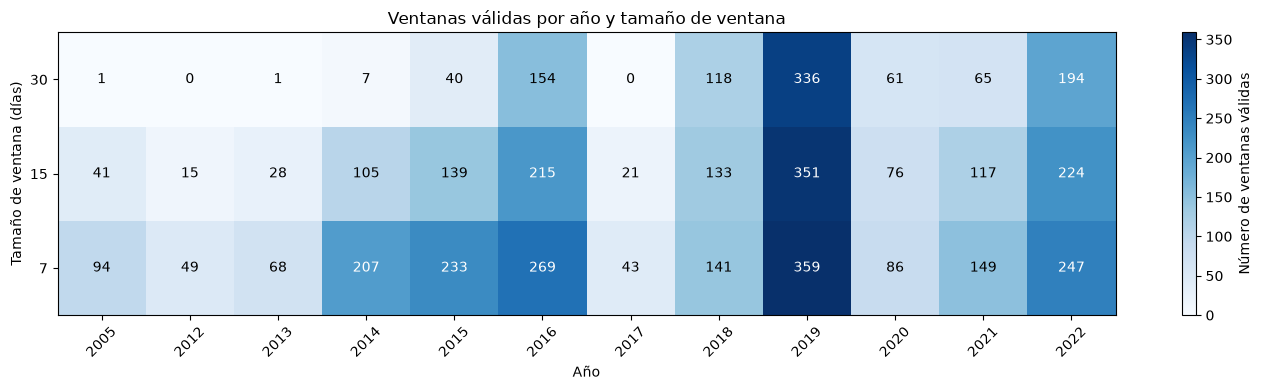

In [13]:

# -----------------------------------------------------------------------------
# Heatmap de ventanas válidas por año y tamaño de ventana
# -----------------------------------------------------------------------------
# Muestra cuántas ventanas completas existen por año para 7, 15 y 30 días.
# Esto ayuda a visualizar si ya quedó un conjunto de ventanas realmente útil.

if 'ventanas_validas' in globals():
    resumen_ventanas = (
        ventanas_validas.groupby(['anio', 'window_size'])
        .size()
        .reset_index(name='n_ventanas_validas')
    )

    heatmap_df = resumen_ventanas.pivot(
        index='window_size',
        columns='anio',
        values='n_ventanas_validas'
    ).fillna(0).astype(int).sort_index(ascending=False)

    print('Conteo de ventanas válidas por año y tamaño de ventana:')
    print(heatmap_df)

    fig, ax = plt.subplots(figsize=(14, max(4, len(heatmap_df.index) * 1.2)))
    im = ax.imshow(heatmap_df.values, cmap='Blues', aspect='auto')

    ax.set_xticks(range(len(heatmap_df.columns)))
    ax.set_xticklabels(heatmap_df.columns, rotation=45)
    ax.set_yticks(range(len(heatmap_df.index)))
    ax.set_yticklabels(heatmap_df.index)

    for i in range(heatmap_df.shape[0]):
        for j in range(heatmap_df.shape[1]):
            value = heatmap_df.iloc[i, j]
            ax.text(j, i, str(value), ha='center', va='center', color='black' if value < max(heatmap_df.max().max() / 2, 1) else 'white')

    ax.set_title('Ventanas válidas por año y tamaño de ventana')
    ax.set_xlabel('Año')
    ax.set_ylabel('Tamaño de ventana (días)')
    fig.colorbar(im, ax=ax, label='Número de ventanas válidas')
    plt.tight_layout()
    plt.show()
else:
    print('Primero debes ejecutar el bloque de generación de ventanas válidas para crear la tabla ventanas_validas.')
